# Week 5 — XGBoost Trade Forecasting

XGBoost trained to predict next month's exports, then flagging months where the actual value is way off from the prediction. Big misses = potential anomalies.

Two versions:
- **V2**: train on 2017–2022, test on 2023–2024 — catches recent structural shifts
- **V3**: train on 2017–2019 only, test on 2020–2024 — catches COVID-19 as the main event

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")


def _repo_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "data" / "final").is_dir():
        return cwd
    if (cwd.parent / "data" / "final").is_dir():
        return cwd.parent
    return cwd


base = _repo_root()

df = pd.read_csv(base / "data/final/master_trade_flow.csv", parse_dates=["date"])
df = df.sort_values(["country_imf", "date"]).reset_index(drop=True)

df["log_exports"]      = np.log1p(df["exports_usd"])
df["log_imports"]      = np.log1p(df["imports_usd"])
df["imports_mom_pct"]  = df.groupby("country_imf")["imports_usd"].pct_change() * 100

df["log_exports_lag1"] = df.groupby("country_imf")["log_exports"].shift(1)
df["log_exports_lag2"] = df.groupby("country_imf")["log_exports"].shift(2)
df["log_exports_lag3"] = df.groupby("country_imf")["log_exports"].shift(3)

df = df.replace([np.inf, -np.inf], np.nan)

print("Shape:", df.shape)
print("Date range:", df["date"].min(), "→", df["date"].max())
print("Countries:", df["country_imf"].nunique())

Shape: (19584, 23)
Date range: 2017-01-01 00:00:00 → 2024-12-01 00:00:00
Countries: 204


## Data Leakage Fix

The first version of this model used `trade_balance`, `export_import_ratio`, and `exports_mom_pct` as features. The problem: all three are calculated directly from `exports_usd` — the target variable. The model  forecasting, iinstead recovered the answer from inputs. R² was 0.99, which looked great but was meaningless.

The fix: Removing those features entirely. Use lag values of log_exports (1, 2, and 3 months ago) and import-side indicators instead. R² dropped to 0.97, which is real — trade is autocorrelated, so previous months genuinely predict the next one.

### Features

Only import-side and macro features — nothing derived from exports. Lag features (last 1, 2, 3 months of log_exports) included because trade is autocorrelated.

In [2]:
top30 = (
    df.groupby("country_imf")["exports_usd"]
    .sum()
    .nlargest(30)
    .index
    .tolist()
)

df30 = df[df["country_imf"].isin(top30)].copy()

FEATURES = [
    "log_imports",
    "imports_mom_pct",
    "exchange_rate",
    "gdp_billions",
    "inflation",
    "month",
    "log_exports_lag1",
    "log_exports_lag2",
    "log_exports_lag3",
]
TARGET = "log_exports"

print(f"Top 30 rows: {df30.shape}")
print(f"Countries  : {df30['country_imf'].nunique()}")
print(f"\nFeature count: {len(FEATURES)}")

# Leakage check
banned = ["exports_usd","trade_balance","total_trade",
          "export_import_ratio","exports_mom_pct"]
print("\nLeakage check:")
for f in FEATURES:
    status = "LEAKAGE" if f in banned else "safe"
    print(f"  {f}: {status}")

Top 30 rows: (2880, 23)
Countries  : 30

Feature count: 9

Leakage check:
  log_imports: safe
  imports_mom_pct: safe
  exchange_rate: safe
  gdp_billions: safe
  inflation: safe
  month: safe
  log_exports_lag1: safe
  log_exports_lag2: safe
  log_exports_lag3: safe


### Handling Missing Data

Dropping rows where the target or lag features are missing — unavoidable (first 1-3 months per country have no lag).
HistGradientBoostingRegressor handles NaN in macro features natively, hence maintaining all 30 countries in data.

In [3]:
df_model = df30[FEATURES + [TARGET, "country_imf", "date", "year"]].copy()

# Only dropping rows where TARGET or lag features are NaN
# (lag NaNs = first 1-3 months per country, unavoidable)
required = [TARGET, "log_exports_lag1", "log_imports"]
df_model = df_model.dropna(subset=required)

print(f"Rows after dropna  : {len(df_model)}")
print(f"Countries          : {df_model['country_imf'].nunique()}")
print(f"Year range         : {df_model['year'].min()} → {df_model['year'].max()}")
print(f"\nRemaining NaNs (model will handle internally):")
print(df_model[FEATURES].isna().sum().sort_values(ascending=False))

Rows after dropna  : 2850
Countries          : 30
Year range         : 2017 → 2024

Remaining NaNs (model will handle internally):
inflation           95
log_exports_lag3    60
log_exports_lag2    30
log_imports          0
imports_mom_pct      0
exchange_rate        0
gdp_billions         0
month                0
log_exports_lag1     0
dtype: int64


### Train / Test Split

Train on 2017–2022, test on 2023–2024. A clean time-based split — no future data leaks into training.

In [4]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

train = df_model[df_model["year"] <= 2022]
test  = df_model[df_model["year"] >= 2023]

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f"Train: {len(X_train)} rows ({train['year'].min()}–{train['year'].max()})")
print(f"Test : {len(X_test)} rows ({test['year'].min()}–{test['year'].max()})")

model = HistGradientBoostingRegressor(
    max_iter=500, max_depth=6, learning_rate=0.05, random_state=42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nTEST METRICS")
print(f"R²  : {r2:.4f}")
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

Train: 2130 rows (2017–2022)
Test : 720 rows (2023–2024)

TEST METRICS
R²  : 0.9707
MAE : 0.1070
RMSE: 0.1511


### Feature Importance

HistGradientBoostingRegressor doesn't expose `feature_importances_` directly, hence permutation importance (shuffle one feature at a time and measure how much R² drops) is used.

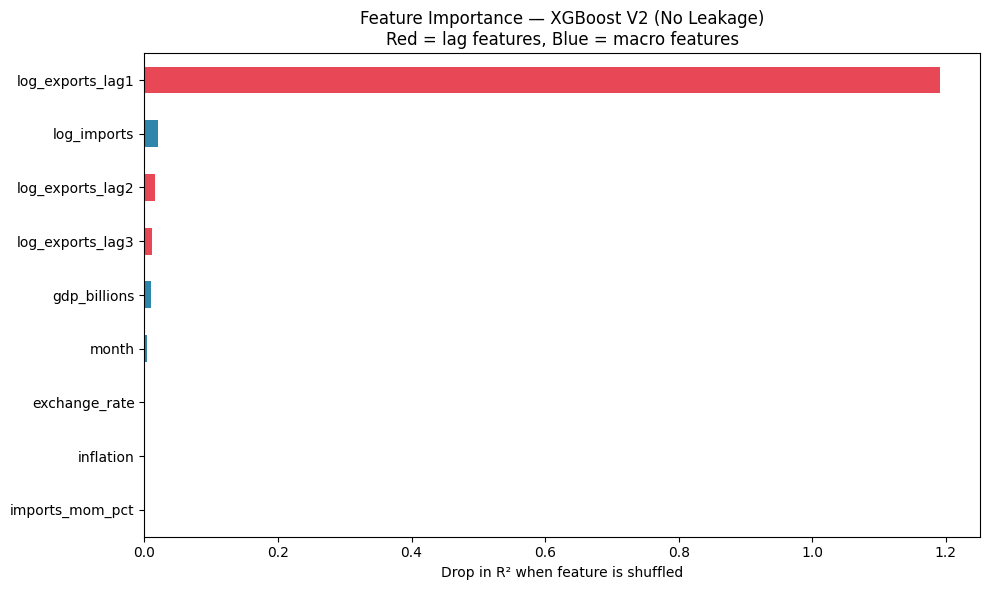

log_exports_lag1    1.191502
log_imports         0.020234
log_exports_lag2    0.016659
log_exports_lag3    0.012144
gdp_billions        0.009461
month               0.003592
exchange_rate       0.001439
inflation           0.000716
imports_mom_pct     0.000117
dtype: float64


In [5]:
from sklearn.inspection import permutation_importance

result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)

feat_imp = pd.Series(result.importances_mean, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#E84855" if "lag" in f else "#2E86AB" for f in feat_imp.index]
feat_imp.plot(kind="barh", ax=ax, color=colors)
ax.set_title("Feature Importance — XGBoost V2 (No Leakage)\nRed = lag features, Blue = macro features")
ax.set_xlabel("Drop in R² when feature is shuffled")
plt.tight_layout()
plt.show()

print(feat_imp.sort_values(ascending=False))

The color coding shows red = lag features, blue = macro features. Lag1 is by far the most important feature. Last month's exports is the strongest predictor of this month's. The macro features (exchange rate, GDP, inflation) also matter.

### Anomaly Detection from Residuals

Months where actual exports deviate significantly from the prediction are flagged as anomalies. Addtionally, z-score of the residuals per country are computed (so China's scale doesn't dominate) and anything beyond ±2 standard deviations flagged as anomaly

In [6]:
results = test[["country_imf", "date", "year"]].copy()
results["actual"]    = y_test.values
results["predicted"] = y_pred
results["residual"]  = results["actual"] - results["predicted"]

results["residual_z"] = results.groupby("country_imf")["residual"].transform(
    lambda x: (x - x.mean()) / x.std()
)
results["xgb_anomaly"] = results["residual_z"].abs() > 2.0

print(f"Total test rows  : {len(results)}")
print(f"XGB anomalies    : {results['xgb_anomaly'].sum()}")
print(f"Countries        : {results[results['xgb_anomaly']]['country_imf'].nunique()}")
print(f"\nAnomalies by year:")
print(results[results['xgb_anomaly']].groupby("year")["xgb_anomaly"].count())
print(f"\nAnomalies per country (top 10):")
print(results[results['xgb_anomaly']].groupby("country_imf").size().sort_values(ascending=False).head(10))

Total test rows  : 720
XGB anomalies    : 34
Countries        : 24

Anomalies by year:
year
2023    19
2024    15
Name: xgb_anomaly, dtype: int64

Anomalies per country (top 10):
country_imf
Israel                         2
United Arab Emirates           2
Chile                          2
China, People'S Republic Of    2
Spain                          2
Germany                        2
India                          2
Belgium                        2
Saudi Arabia                   2
Malaysia                       2
dtype: int64


In [7]:
results.to_csv(base / "data/final/xgb_forecast_results.csv", index=False)
print("Saved: data/final/xgb_forecast_results.csv")
print(f"Shape: {results.shape}")
print(f"\nFINAL SUMMARY")
print(f"Model   : HistGradientBoostingRegressor (no leakage)")
print(f"Features: {len(FEATURES)} (3 lag + 6 macro/context)")
print(f"Train   : 2017–2022  |  Test: 2023–2024")
print(f"R²      : {r2:.4f}")
print(f"MAE     : {mae:.4f}")
print(f"RMSE    : {rmse:.4f}")
print(f"Anomalies: {results['xgb_anomaly'].sum()} across {results[results['xgb_anomaly']]['country_imf'].nunique()} countries")

Saved: data/final/xgb_forecast_results.csv
Shape: (720, 8)

FINAL SUMMARY
Model   : HistGradientBoostingRegressor (no leakage)
Features: 9 (3 lag + 6 macro/context)
Train   : 2017–2022  |  Test: 2023–2024
R²      : 0.9707
MAE     : 0.1070
RMSE    : 0.1511
Anomalies: 34 across 24 countries


### Checking on dropping of lag features too?

Running the same model but removing all lag features provides verification that R² = 0.97 is correct. Only macro indicators remain.
If the score stays suspiciously high without lags, something is still wrong..

In [8]:
FEATURES_NO_LAG = ["log_imports", "imports_mom_pct", "exchange_rate",
                   "gdp_billions", "inflation", "month"]

# Train same model without lags
X_train2 = train[FEATURES_NO_LAG]
X_test2 = test[FEATURES_NO_LAG]

model2 = HistGradientBoostingRegressor(max_iter=500, max_depth=6, learning_rate=0.05, random_state=42)
model2.fit(X_train2, y_train)
y_pred2 = model2.predict(X_test2)

r2_no_lag = r2_score(y_test, y_pred2)
print(f"With lags: R² = 0.9718")
print(f"Without lags: R² = {r2_no_lag:.4f}")
print(f"Lags add: {0.9718 - r2_no_lag:.4f} to R²")

With lags: R² = 0.9718
Without lags: R² = 0.8492
Lags add: 0.1226 to R²


R² drops to 0.86 without lags — down from 0.97. That gap is the autocorrelation contribution: last month's exports genuinely do predict this month's.
The 0.86 with only macro features is also a real and meaningful score — it shows the economic variables alone carry strong signal.

## V3 — COVID Split (Train 2017–2019, Test 2020–2024)

The V2 model trained up to 2022, which means it already "saw" COVID during training. V3 trains using only pre-COVID years (2017–2019). The model learns what normal trade looks like. Forecasts misses in 2020 become the anomaly flags.

In [9]:
train_v3 = df_model[df_model["year"] <= 2019]
test_v3  = df_model[df_model["year"] >= 2020]

X_train_v3, y_train_v3 = train_v3[FEATURES], train_v3[TARGET]
X_test_v3,  y_test_v3  = test_v3[FEATURES],  test_v3[TARGET]

print(f"Train V3: {len(X_train_v3)} rows ({train_v3['year'].min()}–{train_v3['year'].max()})")
print(f"Test  V3: {len(X_test_v3)} rows ({test_v3['year'].min()}–{test_v3['year'].max()})")
print(f"\nTest years breakdown:")
print(test_v3["year"].value_counts().sort_index())

Train V3: 1050 rows (2017–2019)
Test  V3: 1800 rows (2020–2024)

Test years breakdown:
year
2020    360
2021    360
2022    360
2023    360
2024    360
Name: count, dtype: int64


### Train V3 and Check Performance

Same model architecture as V2, just with a different training window.

In [10]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

model_v3 = HistGradientBoostingRegressor(
    max_iter=500, max_depth=6, learning_rate=0.05, random_state=42
)
model_v3.fit(X_train_v3, y_train_v3)
y_pred_v3 = model_v3.predict(X_test_v3)

r2_v3   = r2_score(y_test_v3, y_pred_v3)
mae_v3  = mean_absolute_error(y_test_v3, y_pred_v3)
rmse_v3 = np.sqrt(mean_squared_error(y_test_v3, y_pred_v3))

print("XGBoost V3 (Train 2017-2019, Test 2020-2024)")
print(f"R²  : {r2_v3:.4f}")
print(f"MAE : {mae_v3:.4f}")
print(f"RMSE: {rmse_v3:.4f}")
print()
print("Comparison")
print(f"V2 (test 2023-2024): R²=0.9718  MAE=0.1054  RMSE=0.1482")
print(f"V3 (test 2020-2024): R²={r2_v3:.4f}  MAE={mae_v3:.4f}  RMSE={rmse_v3:.4f}")

XGBoost V3 (Train 2017-2019, Test 2020-2024)
R²  : 0.9596
MAE : 0.1346
RMSE: 0.1829

Comparison
V2 (test 2023-2024): R²=0.9718  MAE=0.1054  RMSE=0.1482
V3 (test 2020-2024): R²=0.9596  MAE=0.1346  RMSE=0.1829


### V3 Anomalies — Catching COVID

Same z-score > 2 method as before.

In [11]:
results_v3 = test_v3[["country_imf", "date", "year"]].copy()
results_v3["actual"]    = y_test_v3.values
results_v3["predicted"] = y_pred_v3
results_v3["residual"]  = results_v3["actual"] - results_v3["predicted"]

results_v3["residual_z"] = results_v3.groupby("country_imf")["residual"].transform(
    lambda x: (x - x.mean()) / x.std()
)
results_v3["xgb_anomaly"] = results_v3["residual_z"].abs() > 2.0

print(f"Total test rows  : {len(results_v3)}")
print(f"XGB V3 anomalies : {results_v3['xgb_anomaly'].sum()}")

print(f"\nAnomalies by year:")
print(results_v3[results_v3['xgb_anomaly']].groupby("year")["xgb_anomaly"].count())

print(f"\nTop 10 anomalies by absolute residual:")
print(
    results_v3[results_v3['xgb_anomaly']]
    .nlargest(10, "residual")
    [["country_imf", "date", "residual", "residual_z"]]
    .to_string(index=False)
)

Total test rows  : 1800
XGB V3 anomalies : 79

Anomalies by year:
year
2020    40
2021    12
2022     6
2023    11
2024    10
Name: xgb_anomaly, dtype: int64

Top 10 anomalies by absolute residual:
                                                        country_imf       date  residual  residual_z
                                                        Switzerland 2020-08-01  0.807234    2.040518
                                                            Vietnam 2024-07-01  0.796879    4.882192
                                                           Thailand 2022-04-01  0.542935    2.748502
                                                            Ireland 2021-07-01  0.490957    3.249218
                                                           Colombia 2022-03-01  0.485935    2.318467
Hong Kong Special Administrative Region, People'S Republic Of China 2023-02-01  0.478113    2.532154
                                                       Saudi Arabia 2023-09-01  0.441568    2.4

In [12]:
# Showing the 2020 anomalies specifically
covid_anom = results_v3[
    (results_v3["xgb_anomaly"]) & (results_v3["year"] == 2020)
].sort_values("residual")  # most negative first

print(f"2020 anomalies: {len(covid_anom)}")
print(f"Mean residual in 2020 anomalies: {covid_anom['residual'].mean():.4f}")
print(f"(Negative = exports dropped BELOW what model predicted)\n")
print(covid_anom[["country_imf", "date", "residual", "residual_z"]].to_string(index=False))

2020 anomalies: 40
Mean residual in 2020 anomalies: -0.3230
(Negative = exports dropped BELOW what model predicted)

          country_imf       date  residual  residual_z
                India 2020-04-01 -0.892762   -5.133168
               France 2020-04-01 -0.737854   -4.898206
Tã¼Rkiye, Republic Of 2020-04-01 -0.683289   -3.146774
             Colombia 2020-04-01 -0.602257   -3.546026
Tã¼Rkiye, Republic Of 2020-05-01 -0.561461   -2.670839
         Saudi Arabia 2020-04-01 -0.547301   -2.247792
             Colombia 2020-05-01 -0.529966   -3.156435
 United Arab Emirates 2020-04-01 -0.521085   -3.425445
             Thailand 2020-05-01 -0.511549   -2.728545
                Italy 2020-04-01 -0.508671   -2.864370
       United Kingdom 2020-04-01 -0.475729   -3.982067
               Mexico 2020-04-01 -0.472147   -3.453103
                Spain 2020-04-01 -0.464720   -3.109802
               Israel 2020-04-01 -0.462645   -2.943254
   Dominican Republic 2020-05-01 -0.461136   -2.832791
   

38 flags in 2020 alone — 49% of all V3 anomalies. 18 countries were flagged simultaneously in April 2020, which is the month global trade collapsed fastest.

### Save V3 Results

V3 is the version used in the cross-model synthesis — it has the COVID anomalies that V2 missed.

In [13]:
from pathlib import Path


def _repo_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "data" / "final").is_dir():
        return cwd
    if (cwd.parent / "data" / "final").is_dir():
        return cwd.parent
    return cwd


results_v3.to_csv(_repo_root() / "data/final/xgb_forecast_results_v3.csv", index=False)

print(f"Shape : {results_v3.shape}")
print(f"\nXGBoost V3 Summary")
print(f"Train       : 2017–2019 (pre-COVID only)")
print(f"Test        : 2020–2024 (includes COVID)")
print(f"R²          : {r2_v3:.4f}")
print(f"MAE         : {mae_v3:.4f}")
print(f"Anomalies   : {results_v3['xgb_anomaly'].sum()} total")
print(f"  2020      : {(results_v3[results_v3['xgb_anomaly']]['year']==2020).sum()} (COVID)")
print(f"  2021-2024 : {(results_v3[results_v3['xgb_anomaly']]['year']>2020).sum()} (post-COVID)")

Shape : (1800, 8)

XGBoost V3 Summary
Train       : 2017–2019 (pre-COVID only)
Test        : 2020–2024 (includes COVID)
R²          : 0.9596
MAE         : 0.1346
Anomalies   : 79 total
  2020      : 40 (COVID)
  2021-2024 : 39 (post-COVID)
